<a href="https://colab.research.google.com/github/SathyaPrakashD/Classical-ML-Pipeline/blob/main/BreastCancer_Sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# ROUND 1 — CHECKPOINT 1 — Load & Inspect
# ============================================================

from sklearn.datasets import load_breast_cancer
import pandas as pd

# Step 1 — Load the dataset
data = load_breast_cancer()

# Step 2 — Create DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Step 3 — Add target
df['target'] = data.target

# Step 4 — Inspect
print("Shape:", df.shape)
print("Classes:", data.target_names)
print("Class counts:\n", df['target'].value_counts())


Shape: (569, 31)
Classes: ['malignant' 'benign']
Class counts:
 target
1    357
0    212
Name: count, dtype: int64
Class counts:
 target_names
malignant    1
benign       1
Name: count, dtype: int64


In [ ]:
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [ ]:
# ============================================================
# ROUND 1 — CHECKPOINT 2 — Split & Scale
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Step 1 — Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Step 2 — Split first (remember why!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

# Step 3 — Fit scaler on train only
scaler = StandardScaler()
scaler.fit(X_train,y_train)

# Step 4 — Transform both
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Step 5 — Verify scaling
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print("\nBEFORE scaling — mean area:", round(df['mean area'].mean(), 2))
print("AFTER scaling  — mean area:", round(X_train_df['mean area'].mean(), 2))

Train size: 455
Test size: 114

BEFORE scaling — mean area: 654.89
AFTER scaling  — mean area: -0.0


In [ ]:
# ============================================================
# ROUND 1 — CHECKPOINT 3 — Train & Predict
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Step 1 — Create model
model = LogisticRegression(max_iter=200)

# Step 2 — Train on scaled train data
model.fit(X_train_scaled, y_train)

# Step 3 — Predict on scaled test data
y_pred = model.predict(X_test_scaled)

# Step 4 — Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))

# Step 5 — Inspect first prediction
print("\nFirst test sample — true label   :", y_test.values[0])
print("First test sample — predicted    :", y_pred[0])
print("First test sample — probabilities:",
      model.predict_proba(X_test_scaled)[0].round(3))

# Step 6 — Map prediction to class name
# Hint: data.target_names[prediction] gives you the class name
print("Predicted class name:", data.target_names[y_pred[0]])
print("True class name     :", data.target_names[y_test.values[0]])

Accuracy: 0.9737

First test sample — true label   : 1
First test sample — predicted    : 1
First test sample — probabilities: [0.114 0.886]
Predicted class name: benign
True class name     : benign


In [ ]:
# ============================================================
# ROUND 1 — CHECKPOINT 4 — Cross Validation
# ============================================================

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Step 1 — Build pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=200))
])

# Step 2 — Cross validate
scores = cross_val_score(pipeline, X, y, cv=5)

# Step 3 — Print results
print("Fold scores :", scores.round(4))
print("Mean accuracy:", round(scores.mean(), 4))
print("Std deviation:", round(scores.std(), 4))

# Step 4 — Compare to single split
print("\nSingle split accuracy :", 0.9737)
print("Cross-val mean accuracy:", round(scores.mean(), 4))
print("More trustworthy       : cross-val")

Fold scores : [0.9825 0.9825 0.9737 0.9737 0.9912]
Mean accuracy: 0.9807
Std deviation: 0.0065

Single split accuracy : 0.9737
Cross-val mean accuracy: 0.9807
More trustworthy       : cross-val


In [ ]:
# ============================================================
# ROUND 1 — CHECKPOINT 5 — Random Forest vs Logistic Regression
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Step 1 — Build Random Forest pipeline
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Step 2 — Cross validate Random Forest
rf_scores = cross_val_score(rf_pipeline, X, y, cv=5)

# Step 3 — Print comparison
print("Logistic Regression — mean: 0.9807  std: 0.0065")
print(f"Random Forest       — mean: {rf_scores.mean():.4f}  std: {rf_scores.std():.4f}")

# Step 4 — Winner
if rf_scores.mean() > 0.9807:
    print("\nRandom Forest wins!")
elif rf_scores.mean() < 0.9807:
    print("\nLogistic Regression wins!")
else:
    print("\nIt's a tie!")

# Step 5 — New this round: does the winner change with more trees?
rf_pipeline_large = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=500, random_state=42))  # try 500
])
rf_scores_large = cross_val_score(rf_pipeline_large, X, y, cv=5)
print(f"\nRandom Forest (500 trees) — mean: {rf_scores_large.mean():.4f}  std: {rf_scores_large.std():.4f}")

Logistic Regression — mean: 0.9807  std: 0.0065
Random Forest       — mean: 0.9561  std: 0.0228

Logistic Regression wins!

Random Forest (500 trees) — mean: 0.9614  std: 0.0212


Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



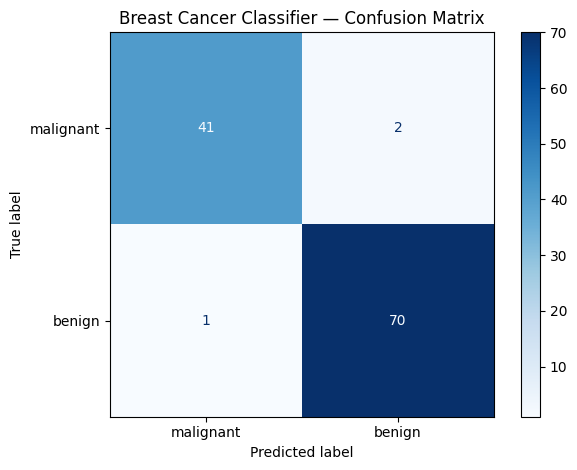


False Negatives (malignant → predicted benign): 0
Out of 43 actual malignant cases


In [ ]:
# ============================================================
# ROUND 1 — CHECKPOINT 6 — Full Evaluation Report
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Step 1 — Retrain best model (Logistic Regression) on train set
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=200))
])
final_model.fit(X_train_scaled, y_train)

# Step 2 — Predict
y_pred = final_model.predict(X_test_scaled)

# Step 3 — Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# Step 4 — Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title("Breast Cancer Classifier — Confusion Matrix")
plt.tight_layout()
plt.show()

# Step 5 — New this round: extract the dangerous errors
# False Negatives = malignant predicted as benign
# These are the most dangerous mistakes in medical diagnosis
y_test_arr = y_test.values
false_negatives = sum(
    1 for true, pred in zip(___, ___)
    if true == 0 and pred == 1
)
print(f"\nFalse Negatives (malignant → predicted benign): {false_negatives}")
print(f"Out of {sum(y_test_arr == 0)} actual malignant cases")